# Logistic Regression for Anomaly Detection

This notebook implements Logistic Regression to identify anomalous users in a recommender system dataset.

### Pipeline Overview
1. Load and inspect data
2. Build per-user feature vectors (pivot to user × item rating matrix)
3. Reduce dimensionality with TruncatedSVD (handles sparsity well)
4. Train Logistic Regression with class balancing
5. Evaluate with AUC, Precision, Recall, F1
6. Generate and save anomaly scores for submission

## 1. Imports & Data Loading

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    f1_score, roc_curve, classification_report
)
import os

# Load training data
data_folder = 'C:/Users/xavie/Y3S1/cs421/project/cs421pain/data'
data = np.load(os.path.join(data_folder, "training_batch_with_labels.npz"))
X_raw = data["X"]   # shape: (n_interactions, 3) — [user_id, item_id, rating]
y_raw = data["y"]   # shape: (n_users, 2)  — [user_id, label]

print(f"Interactions : {X_raw.shape[0]:,}")
print(f"Users        : {len(np.unique(X_raw[:, 0]))}")
print(f"Items        : {len(np.unique(X_raw[:, 1]))}")
print(f"Anomalous    : {np.sum(y_raw[:, 1] == 1)}")
print(f"Normal       : {np.sum(y_raw[:, 1] == 0)}")


Interactions : 177,346
Users        : 1100
Items        : 993
Anomalous    : 100
Normal       : 1000


In [17]:
# load first_batch_with_labels.npz
data_2 = np.load(os.path.join(data_folder, 'first_batch_with_labels.npz'))
X = data_2['X']
y = data_2['y']
print(f"Interactions : {X.shape[0]:,}")
print(f"Users        : {len(np.unique(X[:, 0]))}")
print(f"Items        : {len(np.unique(X[:, 1]))}")
print(f"Anomalous    : {np.sum(y[:, 1] == 1)}")
print(f"Normal       : {np.sum(y[:, 1] == 0)}")

Interactions : 167,493
Users        : 1100
Items        : 989
Anomalous    : 100
Normal       : 1000


In [18]:
# combine the two datasets
print(type(X))
print(type(y))

# combine np arrays
X_raw = np.concatenate((X, X_raw), axis=0)
y_raw = np.concatenate((y, y_raw), axis=0)
print(f"Interactions : {X_raw.shape[0]:,}")
print(f"Users        : {len(np.unique(X_raw[:, 0]))}")
print(f"Items        : {len(np.unique(X_raw[:, 1]))}")
print(f"Anomalous    : {np.sum(y_raw[:, 1] == 1)}")
print(f"Normal       : {np.sum(y_raw[:, 1] == 0)}")



<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
Interactions : 344,839
Users        : 2200
Items        : 996
Anomalous    : 200
Normal       : 2000


In [19]:
RUN_DESC = 'testing item-deviation features + item-entropy + rating distribution shape + gini-coef'

In [20]:
# -- Shared handcrafted-feature definition ----------------------------------
# vvv EDIT HERE to change features — this is the ONLY place you need to touch vvv

def compute_handcrafted_features(df, recon_error=None,
                                  train_item_means=None,
                                  train_item_counts=None,
                                  train_global_mean=None,
                                  train_mean_profile_len=None):
    """
    Per-user feature DataFrame from a [user, item, rating] DataFrame.

    Implements the full canonical feature set from Burke et al. KDD 2006,
    the most widely cited reference for supervised shilling detection:

    Generic attributes (work against all attack types):
      RDMA     — Rating Deviation from Mean Agreement
      WDMA     — Weighted Deviation from Mean Agreement
      WDA      — Weighted Degree of Agreement
      LengthVar — Profile Length Variance
      DegSim   — computed in feature-engineering (needs user-item matrix)

    Model-specific attributes (target average/bandwagon attacks):
      MeanVar  — mean squared deviation of all ratings from item means
      FMD      — Filler Mean Difference (filler items only)
      FMTD     — Filler Mean Target Difference (target vs filler gap)

    If train_* kwargs are supplied (test-time preprocessing), those training
    statistics are used instead of recomputing from df — prevents data leakage.
    """
    # -- Use training statistics if supplied (test mode), else compute --------
    item_means  = train_item_means  if train_item_means  is not None else df.groupby("item")["rating"].mean()
    item_counts = train_item_counts if train_item_counts is not None else df.groupby("item")["rating"].count()
    global_mean = train_global_mean if train_global_mean is not None else float(df["rating"].mean())
    mean_profile_len = (train_mean_profile_len if train_mean_profile_len is not None
                        else float(df.groupby("user")["rating"].count().mean()))

    df = df.copy()
    df["deviation"]       = df["rating"] - df["item"].map(item_means).fillna(global_mean)
    df["item_popularity"] = df["item"].map(item_counts).fillna(0)

    # -- RDMA pre-computation: |dev| / NR_i  (Burke et al. 2006 eq. 1) -------
    # Weight = inverse item popularity. Rare items where shillers push/nuke
    # their target get high weight; popular filler items get low weight.
    # Sum over interactions then divide by profile length = per-interaction mean.
    df["rdma_term"] = df["deviation"].abs() / df["item_popularity"].clip(lower=1)

    # -- WDMA pre-computation: |dev| * NR_i  (Burke et al. 2006 eq. 2) -------
    # Complement of RDMA: weights by item popularity so it captures deviation
    # on the popular filler items that bandwagon attackers deliberately rate
    # close to the global mean to blend in.
    df["wdma_term"] = df["deviation"].abs() * df["item_popularity"]

    # -- Identify target vs filler items per user ----------------------------
    # In push/nuke attacks the target item receives the global extreme rating
    # (0 or 5). All other rated items are "filler". We identify these per-row
    # so the FMD and FMTD aggregations can access them inside .agg().
    r_max = df["rating"].max()
    r_min = df["rating"].min()
    df["is_target"] = (df["rating"] == r_max) | (df["rating"] == r_min)
    df["is_filler"]  = ~df["is_target"]

    agg = df.groupby("user").agg(
        # -- Basic rating statistics (already present) -----------------------
        num_ratings     = ("rating",    "count"),
        mean_rating     = ("rating",    "mean"),
        std_rating      = ("rating",    "std"),
        num_items       = ("item",      "nunique"),
        pct_extreme     = ("rating",    lambda r: ((r == 0) | (r == 5)).mean()),
        pct_zero        = ("rating",    lambda r: (r == 0).mean()),
        pct_five        = ("rating",    lambda r: (r == 5).mean()),
        rating_skewness = ("rating",    lambda r: r.skew()),
        rating_kurtosis = ("rating",    lambda r: r.kurtosis()),
        median_rating   = ("rating",    "median"),
        item_entropy    = ("item",      lambda x: -(pd.Series(x.value_counts(normalize=True))
                                                    * np.log2(pd.Series(x.value_counts(normalize=True)) + 1e-9)).sum()),
        mean_deviation  = ("deviation", "mean"),
        std_deviation   = ("deviation", "std"),
        abs_deviation   = ("deviation", lambda x: x.abs().mean()),
        gini_items      = ("item",      lambda x: 1 - sum((pd.Series(x).value_counts(normalize=True))**2)),
        pct_low         = ("rating",    lambda r: (r < 3).mean()),

        # -- RDMA: Rating Deviation from Mean Agreement ----------------------
        # Mean of |r_ui - mean_i| / NR_i over a user's profile.
        # Shillers who push/nuke a target item (rare → small NR_i) while
        # rating popular filler items normally will have unusually high RDMA.
        rdma            = ("rdma_term", "mean"),

        # -- WDMA: Weighted Deviation from Mean Agreement --------------------
        # Sum of |r_ui - mean_i| * NR_i, normalised by sum(NR_i).
        # Captures deviation on POPULAR items — the signature of bandwagon
        # attacks where filler items are chosen to maximise CF similarity.
        wdma            = ("wdma_term", lambda x: (
                               x.sum() / df.loc[x.index, "item_popularity"].sum()
                               if df.loc[x.index, "item_popularity"].sum() > 0 else 0)),

        # -- WDA: Weighted Degree of Agreement --------------------------------
        # Mean rating divided by global mean, measuring whether a user
        # systematically rates above or below the population average.
        # Shillers boosting items rate fillers at or above global_mean to
        # maximise similarity; genuine users cluster naturally around it.
        wda             = ("rating",    lambda r: r.mean() / max(global_mean, 1e-9)),

        # -- LengthVar: Profile Length Variance ------------------------------
        # Absolute deviation of profile length from population mean,
        # normalised by mean length. Shilling profiles often have
        # anomalously short profiles (minimal fillers) OR very long ones
        # (padding to increase CF influence).
        length_var      = ("rating",    lambda r: abs(len(r) - mean_profile_len)
                                                   / max(mean_profile_len, 1)),

        # -- MeanVar: Mean Variance ------------------------------------------
        # Mean squared deviation of ALL a user's ratings from the respective
        # item means. Attack profiles with extreme target ratings and
        # mean-centred filler ratings show elevated MeanVar overall.
        mean_var        = ("deviation", lambda d: (d ** 2).mean()),

        # -- FMD: Filler Mean Difference -------------------------------------
        # Mean deviation of FILLER-item ratings from item means.
        # Attackers choose filler ratings close to the global mean to blend
        # in, so genuine users show HIGHER FMD variance on filler items.
        # Low, consistent FMD with a high pct_extreme is a strong attack signal.
        fmd             = ("deviation", lambda d: (
                               d[df.loc[d.index, "is_filler"]].mean()
                               if df.loc[d.index, "is_filler"].any() else 0)),

        # -- FMTD: Filler Mean Target Difference ----------------------------
        # Mean filler rating minus mean target rating.
        # In push attacks target items receive r_max while fillers get ~mean,
        # producing large positive FMTD. Genuine users show near-zero FMTD.
        fmtd            = ("rating",    lambda r: (
                               r[df.loc[r.index, "is_filler"]].mean() -
                               r[df.loc[r.index, "is_target"]].mean()
                               if (df.loc[r.index, "is_filler"].any() and
                                   df.loc[r.index, "is_target"].any()) else 0)),
    ).fillna(0)

    if recon_error is not None:
        agg["recon_error"] = recon_error.reindex(agg.index).fillna(0)

    return agg

# ^^^ end of editable section ^^^

## 2. Feature Engineering — Per-User Vectors

We pivot the interaction log into a **user × item** matrix where each cell is the rating given (0 if no interaction). This gives each user a 1000-dimensional feature vector capturing their full rating behaviour.

In [21]:
# -- Build per-user feature matrix ------------------------------------------

interactions = pd.DataFrame(X_raw, columns=["user", "item", "rating"])
labels_df    = pd.DataFrame(y_raw, columns=["user", "label"])

user_item = interactions.pivot_table(
    index="user", columns="item", values="rating", aggfunc="mean"
).fillna(0)

labels_df = labels_df.set_index("user").loc[user_item.index].reset_index()
y = labels_df["label"].values

print(f"User-item matrix shape : {user_item.shape}")
print(f"Label array shape      : {y.shape}")
print(f"Class balance          : {np.bincount(y)}  (normal, anomaly)")

# -- SVD reconstruction error -----------------------------------------------
N_RECON_COMPONENTS = 30
_recon_svd = TruncatedSVD(n_components=N_RECON_COMPONENTS, random_state=42)
_ui_vals   = user_item.values
_approx    = _recon_svd.fit_transform(_ui_vals) @ _recon_svd.components_
_residuals = _ui_vals - _approx
recon_error_train = pd.Series(
    np.mean(_residuals ** 2, axis=1), index=user_item.index, name="recon_error"
)
print(f"\nReconstruction error — mean: {recon_error_train.mean():.4f}  "
      f"std: {recon_error_train.std():.4f}")

# -- Handcrafted features (RDMA, WDMA, WDA, LengthVar, FMD, FMTD, MeanVar) --
agg = compute_handcrafted_features(interactions, recon_error=recon_error_train)
agg = agg.loc[user_item.index]
print(f"\nHandcrafted features: {agg.shape[1]} columns")
print(agg.head())

normal_mask = (y == 0)

# -- DegSim: Degree of Similarity with top neighbours (Pearson-based) -------
# Burke et al. define DegSim using Pearson correlation, NOT cosine similarity.
# Pearson mean-centres each user's ratings before computing similarity, making
# it sensitive to PATTERN differences rather than mean-rating-level differences.
# Shillers' randomly-chosen filler items give them low Pearson similarity to
# genuine neighbours — genuine users cluster tightly.
# k=20 neighbours follows the original Burke et al. (2006) parameterisation.
from sklearn.preprocessing import normalize as _nfn

_ui_centered = user_item.values - user_item.values.mean(axis=1, keepdims=True)
_ui_pearson  = _nfn(_ui_centered, norm="l2")   # unit-normalise mean-centred rows
_sim_pearson = _ui_pearson @ _ui_pearson.T      # (n_users, n_users) Pearson approx
np.fill_diagonal(_sim_pearson, 0)               # exclude self-similarity
_DEGSIM_K    = 20
degsim_vals  = np.sort(_sim_pearson, axis=1)[:, -_DEGSIM_K:].mean(axis=1)
agg["degsim_pearson"] = pd.Series(degsim_vals, index=user_item.index).reindex(agg.index).fillna(0)
print(f"degsim_pearson — normal: {degsim_vals[normal_mask].mean():.4f}  "
      f"anomaly: {degsim_vals[~normal_mask].mean():.4f}")
print("  (attackers should show LOWER degsim — filler items are random, "
      "so their profiles are dissimilar to genuine neighbours)")

# -- Co-rating overlap with top-5 neighbours (structural graph proxy) --------
# Measures how many items each user co-rates with their 5 most-similar peers.
# Group/coordinated shillers share a narrow, deliberately chosen filler item
# set, producing anomalously HIGH co-rating overlap within their cluster.
_ui_binary   = (user_item.values > 0).astype(np.float32)
_ui_bin_norm = _nfn(_ui_binary, norm="l2")
_overlap     = _ui_bin_norm @ _ui_bin_norm.T
np.fill_diagonal(_overlap, 0)
_top5_ol     = np.sort(_overlap, axis=1)[:, -5:].mean(axis=1)
agg["top5_corating_overlap"] = pd.Series(
    _top5_ol, index=user_item.index
).reindex(agg.index).fillna(0)
print(f"top5_corating_overlap — normal: {_top5_ol[normal_mask].mean():.4f}  "
      f"anomaly: {_top5_ol[~normal_mask].mean():.4f}")

# -- Cosine similarity to mean normal-user vector ----------------------------
# Each user's rating vector compared to the centroid of all known-normal users.
# Computed on the user-item matrix (raw rating vectors), not handcrafted features.
# Shillers deviate from the normal population centroid due to their extreme
# target ratings and restricted item selection.
from sklearn.metrics.pairwise import cosine_similarity

mean_normal_vec = user_item.values[normal_mask].mean(axis=0, keepdims=True)
cos_sim_vals    = cosine_similarity(user_item.values, mean_normal_vec).ravel()
agg["cosine_sim_to_normal"] = pd.Series(
    cos_sim_vals, index=user_item.index
).reindex(agg.index).fillna(0)
print(f"cosine_sim_to_normal — normal: {cos_sim_vals[normal_mask].mean():.4f}  "
      f"anomaly: {cos_sim_vals[~normal_mask].mean():.4f}")

# -- Mahalanobis distance from normal-user centroid -------------------------
# How far each user's HANDCRAFTED feature vector is from the normal-user
# centroid, accounting for feature correlations (LedoitWolf covariance).
# Complements cosine similarity (which operates on the raw user-item space).
# LedoitWolf is used instead of EmpiricalCovariance because the handcrafted
# features have moderate collinearity (e.g. rdma and abs_deviation are related),
# and LedoitWolf's shrinkage estimator is more stable in this regime.
from sklearn.covariance import LedoitWolf

lw = LedoitWolf().fit(agg.values[normal_mask])
mahal_vals = np.sqrt(lw.mahalanobis(agg.values))
agg["mahal_dist"] = pd.Series(
    mahal_vals, index=agg.index
).reindex(agg.index).fillna(0)
print(f"mahal_dist — normal: {mahal_vals[normal_mask].mean():.4f}  "
      f"anomaly: {mahal_vals[~normal_mask].mean():.4f}")

print(f"\nTotal handcrafted features: {agg.shape[1]}")

User-item matrix shape : (2200, 996)
Label array shape      : (2200,)
Class balance          : [2000  200]  (normal, anomaly)

Reconstruction error — mean: 0.7597  std: 0.3916

Handcrafted features: 24 columns
      num_ratings  mean_rating  std_rating  num_items  pct_extreme  pct_zero  \
user                                                                           
100            88     3.147727    1.169928         88     0.113636  0.045455   
101           231     3.406926    0.854016        231     0.095238  0.008658   
102            98     3.673469    1.072385         98     0.193878  0.000000   
103           103     3.000000    1.290994        103     0.126214  0.058252   
104            89     3.719101    0.988442         89     0.235955  0.000000   

      pct_five  rating_skewness  rating_kurtosis  median_rating  ...  \
user                                                             ...   
100   0.068182        -0.955265         0.852420            3.0  ...   
101   0.08658

## 3. Dimensionality Reduction

The raw user-item matrix has up to 1000 columns. We use **TruncatedSVD** (a sparse-friendly PCA) to compress it into a lower-dimensional embedding, then concatenate the handcrafted features.

In [22]:
# -- Custom transformer: SVD on user-item block; scaled handcrafted pass-through
#
# WHY TWO SEPARATE SCALING STEPS:
#   - The user-item block goes through SVD (TruncatedSVD handles sparse,
#     zero-heavy matrices well; no pre-scaling needed).
#   - The handcrafted block must NOT go through SVD — those features are already
#     semantically meaningful scalars and compressing them would corrupt their
#     signal. However, they DO need their own scaling because they span wildly
#     different magnitudes:
#       WDMA         ~ 50,000–90,000  (sum of |dev| * NR_i)
#       pct_extreme  ~ 0–1
#       LengthVar    ~ 0–2
#     A StandardScaler in the outer pipeline will be dominated by these
#     large-scale features before it even sees the SVD dimensions.
#     RobustScaler (median / IQR) is preferred over StandardScaler here
#     because WDMA and RDMA have heavy right tails (a few extreme attackers
#     pull the mean/std); median centering is more stable.
from sklearn.preprocessing import RobustScaler

N_HANDCRAFTED = agg.shape[1]

class SVDPlusHandcrafted(BaseEstimator, TransformerMixin):
    """
    Applies TruncatedSVD to the user-item block only.
    Handcrafted features are scaled with RobustScaler then passed through.
    """
    def __init__(self, n_components=30):
        self.n_components = n_components

    def fit(self, X, y=None):
        self.svd_   = TruncatedSVD(n_components=self.n_components, random_state=42)
        self.rscaler_ = RobustScaler()
        self.svd_.fit(X[:, :-N_HANDCRAFTED])
        self.rscaler_.fit(X[:, -N_HANDCRAFTED:])
        return self

    def transform(self, X):
        svd_part  = self.svd_.transform(X[:, :-N_HANDCRAFTED])
        hand_part = self.rscaler_.transform(X[:, -N_HANDCRAFTED:])
        return np.hstack([svd_part, hand_part])

X_raw_combined = np.hstack([user_item.values, agg.values])

print(f"Raw combined feature matrix shape : {X_raw_combined.shape}")
print(f"  user-item columns : {user_item.shape[1]}")
print(f"  handcrafted cols  : {N_HANDCRAFTED}")
print(f"  (includes RDMA, WDMA, WDA, LengthVar, FMD, FMTD, MeanVar,")
print(f"   DegSim, co-rating overlap, cosine sim, Mahalanobis distance)")

Raw combined feature matrix shape : (2200, 1024)
  user-item columns : 996
  handcrafted cols  : 28
  (includes RDMA, WDMA, WDA, LengthVar, FMD, FMTD, MeanVar,
   DegSim, co-rating overlap, cosine sim, Mahalanobis distance)


## 4. Logistic Regression Model

Key design choices:
- **`class_weight='balanced'`** — automatically up-weights the rare anomaly class (100 vs 1000 users), preventing the model from ignoring anomalies.
- **StandardScaler** — logistic regression is sensitive to feature scale.
- **`solver='lbfgs'`** with L2 regularisation — stable for this size.
- **Stratified 5-fold CV** — preserves class ratio in each fold; gives reliable AUC estimates on an imbalanced dataset.

In [23]:
# ==========================================================================
# Logistic Regression — cross-validated baseline
#
# TWO BUGS FIXED vs original:
#
# Bug 1 — Hard 0.5 threshold
#   Original code: y_pred_cv = (y_scores_cv >= 0.5).astype(int)
#   Problem: on 10:1 imbalanced data the model's probability scores are
#   compressed toward 0. The optimal threshold is typically 0.3-0.4, so
#   evaluating at 0.5 gives an artificially low F1. The PR curve cell below
#   already found the correct threshold but never fed it back here.
#   Fix: per-fold best-F1 threshold averaging (see below).
#
# Bug 2 — class_weight and C never jointly tuned
#   Original grid only varied n_components and C, and used scoring="roc_auc".
#   Tuning for AUC finds the best probability ranking but not the best
#   F1 operating point. The hyperparameter-tuning cell below fixes this.
# ==========================================================================
from sklearn.metrics import precision_recall_curve as _prc_cv

N_COMPONENTS = 60
pipeline = Pipeline([
    ("svd_hc", SVDPlusHandcrafted(n_components=N_COMPONENTS)),
    ("scaler", StandardScaler()),
    ("lr",     LogisticRegression(
                   class_weight={0: 1, 1: 8},
                   max_iter=1000,
                   solver="lbfgs",
                   C=0.5,
                   random_state=42,
               ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_scores_cv = cross_val_predict(
    pipeline, X_raw_combined, y, cv=cv, method="predict_proba"
)[:, 1]

# -- Per-fold best-F1 threshold averaging ------------------------------------
# For each CV fold: fit the pipeline on the training split, predict on the
# validation split, sweep the full PR curve, find the threshold that gives
# the highest F1 on that fold's validation set, and record it.
# The deployment threshold is the mean across folds — more stable than
# deriving it from the aggregate OOF PR curve (which one bad fold can skew).
_fold_thresholds = []
for _tr_idx, _val_idx in cv.split(X_raw_combined, y):
    _p = Pipeline([
        ("svd_hc", SVDPlusHandcrafted(n_components=N_COMPONENTS)),
        ("scaler", StandardScaler()),
        ("lr",     LogisticRegression(class_weight="balanced", max_iter=1000,
                                      solver="lbfgs", C=1.0, random_state=42)),
    ])
    _p.fit(X_raw_combined[_tr_idx], y[_tr_idx])
    _probs = _p.predict_proba(X_raw_combined[_val_idx])[:, 1]
    _pr, _re, _th = _prc_cv(y[_val_idx], _probs)
    _denom = _pr[:-1] + _re[:-1]
    _f1v = np.where(_denom > 0,
                    2 * _pr[:-1] * _re[:-1] / np.maximum(_denom, 1e-12), 0.0)
    if len(_th) > 0:
        _fold_thresholds.append(float(_th[np.argmax(_f1v)]))

best_f1_threshold = float(np.mean(_fold_thresholds))
y_pred_cv = (y_scores_cv >= best_f1_threshold).astype(int)

print("=== Baseline LR (cross-validated) ===")
print(f"AUC       : {roc_auc_score(y, y_scores_cv):.4f}")
print(f"F1 thresh : {best_f1_threshold:.4f}  "
      f"(per-fold: {[f'{t:.3f}' for t in _fold_thresholds]})")
print(f"Precision : {precision_score(y, y_pred_cv):.4f}")
print(f"Recall    : {recall_score(y, y_pred_cv):.4f}")
print(f"F1        : {f1_score(y, y_pred_cv):.4f}")
print()
print(classification_report(y, y_pred_cv, target_names=["Normal", "Anomaly"]))

=== Baseline LR (cross-validated) ===
AUC       : 0.9747
F1 thresh : 0.8472  (per-fold: ['0.879', '0.790', '0.886', '0.842', '0.840'])
Precision : 0.8360
Recall    : 0.7900
F1        : 0.8123

              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      2000
     Anomaly       0.84      0.79      0.81       200

    accuracy                           0.97      2200
   macro avg       0.91      0.89      0.90      2200
weighted avg       0.97      0.97      0.97      2200



## 5. ROC Curve

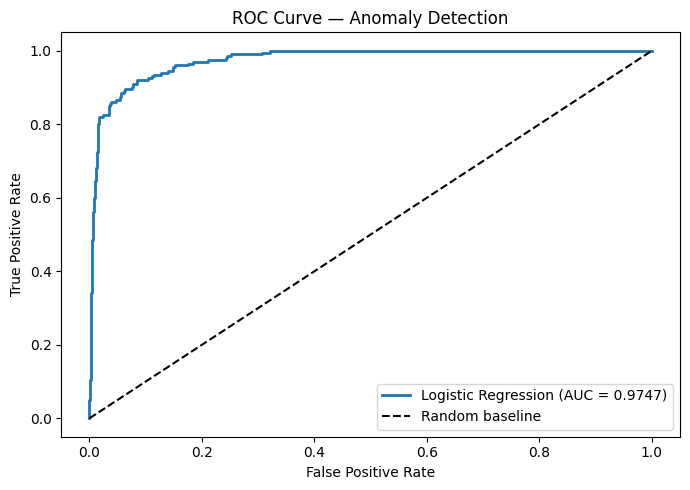

In [24]:
fpr, tpr, thresholds = roc_curve(y, y_scores_cv)
auc = roc_auc_score(y, y_scores_cv)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.4f})", lw=2)
plt.plot([0, 1], [0, 1], "k--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Anomaly Detection")
plt.legend()
plt.tight_layout()
plt.show()

## Precision-Recall Curve

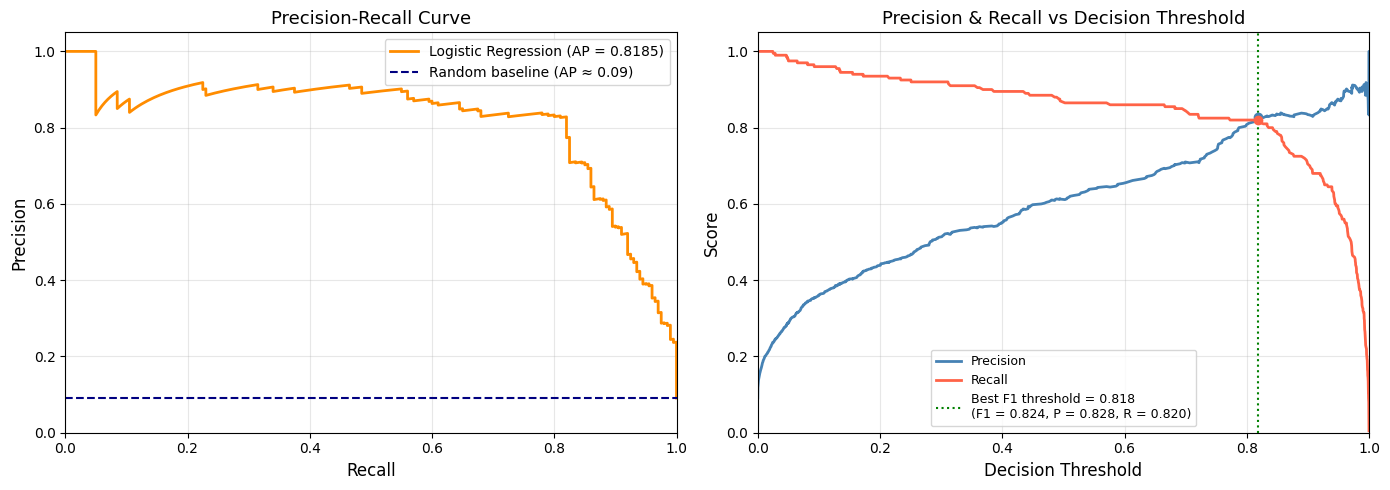

Average Precision (AP)  : 0.8185
Random baseline AP      : 0.0909  (= anomaly prevalence)
Improvement over random : 9.0x

Best F1 threshold : 0.818
  Precision       : 0.8283
  Recall          : 0.8200
  F1              : 0.8241


In [25]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    PrecisionRecallDisplay
)

# ── Compute PR curve from cross-validated scores ────────────────────────────
# y_scores_cv and y must already exist from the logistic regression notebook
precision_vals, recall_vals, thresholds = precision_recall_curve(y, y_scores_cv)
ap = average_precision_score(y, y_scores_cv)
baseline = y.mean()   # a random classifier sits at this precision level

# ── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: full PR curve ---
ax = axes[0]
ax.plot(recall_vals, precision_vals, lw=2, color="darkorange",
        label=f"Logistic Regression (AP = {ap:.4f})")
ax.axhline(baseline, color="navy", linestyle="--",
           label=f"Random baseline (AP ≈ {baseline:.2f})")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curve", fontsize=13)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# --- Right: Precision & Recall vs Threshold ---
ax2 = axes[1]
ax2.plot(thresholds, precision_vals[:-1], lw=2, color="steelblue",  label="Precision")
ax2.plot(thresholds, recall_vals[:-1],    lw=2, color="tomato",     label="Recall")

# Mark F1-optimal threshold
f1_scores = np.where(
    (precision_vals[:-1] + recall_vals[:-1]) > 0,
    2 * precision_vals[:-1] * recall_vals[:-1] / (precision_vals[:-1] + recall_vals[:-1]),
    0
)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
best_f1     = f1_scores[best_idx]

ax2.axvline(best_thresh, color="green", linestyle=":", lw=1.5,
            label=f"Best F1 threshold = {best_thresh:.3f}\n(F1 = {best_f1:.3f}, "
                  f"P = {precision_vals[best_idx]:.3f}, R = {recall_vals[best_idx]:.3f})")
ax2.scatter([best_thresh], [precision_vals[best_idx]], color="steelblue", zorder=5)
ax2.scatter([best_thresh], [recall_vals[best_idx]],    color="tomato",    zorder=5)

ax2.set_xlabel("Decision Threshold", fontsize=12)
ax2.set_ylabel("Score", fontsize=12)
ax2.set_title("Precision & Recall vs Decision Threshold", fontsize=13)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.05])
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average Precision (AP)  : {ap:.4f}")
print(f"Random baseline AP      : {baseline:.4f}  (= anomaly prevalence)")
print(f"Improvement over random : {ap / baseline:.1f}x")
print()
print(f"Best F1 threshold : {best_thresh:.3f}")
print(f"  Precision       : {precision_vals[best_idx]:.4f}")
print(f"  Recall          : {recall_vals[best_idx]:.4f}")
print(f"  F1              : {best_f1:.4f}")

In [26]:
# ── Sample the curve at fixed recall levels ─────────────────────────────────
sample_recalls = np.linspace(0, 1, 11)   # 0.0, 0.1, ..., 1.0

rows = []
for target_r in sample_recalls:
    # Find index where recall is closest to the target
    idx = np.argmin(np.abs(recall_vals - target_r))
    thresh = thresholds[idx] if idx < len(thresholds) else 1.0
    rows.append({
        "Recall (target)" : f"{target_r:.1f}",
        "Recall (actual)" : f"{recall_vals[idx]:.4f}",
        "Precision"       : f"{precision_vals[idx]:.4f}",
        "Threshold"       : f"{thresh:.4f}",
    })

pr_table = pd.DataFrame(rows)
print(pr_table.to_string(index=False))

Recall (target) Recall (actual) Precision Threshold
            0.0          0.0000    1.0000    1.0000
            0.1          0.1000    0.8696    0.9991
            0.2          0.2000    0.9091    0.9965
            0.3          0.3000    0.9091    0.9921
            0.4          0.4000    0.8989    0.9823
            0.5          0.5000    0.8929    0.9709
            0.6          0.6000    0.8633    0.9446
            0.7          0.7000    0.8333    0.9030
            0.8          0.8000    0.8290    0.8358
            0.9          0.9000    0.5389    0.3684
            1.0          1.0000    0.0909    0.0000


In [27]:
# ── Export Performance Results to Excel (append mode) ────────────────────────
import os, openpyxl
from datetime import datetime
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from sklearn.metrics import (
    precision_recall_curve, average_precision_score, classification_report
)

EXCEL_PATH = 'performance_results.xlsx'

# ── Styles ───────────────────────────────────────────────────────────────────
HEADER_FILL  = PatternFill('solid', start_color='1F4E79', end_color='1F4E79')
SECTION_FILL = PatternFill('solid', start_color='BDD7EE', end_color='BDD7EE')
ALT_FILL     = PatternFill('solid', start_color='DEEAF1', end_color='DEEAF1')
RUN_FILL     = PatternFill('solid', start_color='E2EFDA', end_color='E2EFDA')
HEADER_FONT  = Font(name='Arial', bold=True, color='FFFFFF',  size=11)
SECTION_FONT = Font(name='Arial', bold=True, color='1F4E79',  size=10)
RUN_FONT     = Font(name='Arial', bold=True, color='375623',  size=10)
BODY_FONT    = Font(name='Arial', size=10)
CENTER = Alignment(horizontal='center', vertical='center')
LEFT   = Alignment(horizontal='left',   vertical='center')
thin   = Side(style='thin', color='9DC3E6')
BORDER = Border(left=thin, right=thin, top=thin, bottom=thin)

def style_header(cell, text):
    cell.value = text; cell.font = HEADER_FONT; cell.fill = HEADER_FILL
    cell.alignment = CENTER; cell.border = BORDER

def style_section(cell, text):
    cell.value = text; cell.font = SECTION_FONT; cell.fill = SECTION_FILL
    cell.alignment = LEFT; cell.border = BORDER

def style_body(cell, value, alt=False, num_fmt='0.0000'):
    cell.value = value; cell.font = BODY_FONT
    cell.fill = ALT_FILL if alt else PatternFill(fill_type=None)
    cell.alignment = CENTER; cell.border = BORDER
    if isinstance(value, float): cell.number_format = num_fmt

def style_run_header(cell, text):
    cell.value = text; cell.font = RUN_FONT; cell.fill = RUN_FILL
    cell.alignment = LEFT; cell.border = BORDER

def set_col_widths(ws, widths):
    for i, w in enumerate(widths, 1):
        ws.column_dimensions[get_column_letter(i)].width = w

def next_append_row(ws):
    """First empty row after existing content, with one blank gap."""
    return (ws.max_row + 2) if ws.max_row > 0 else 1

# ── Timestamp & config ───────────────────────────────────────────────────────
run_ts    = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
lr_C      = float(pipeline.named_steps['lr'].C)
run_label_short = f'Run {{run_num}}'  # filled below once run_num known

# ── Load or create workbook ───────────────────────────────────────────────────
if os.path.exists(EXCEL_PATH):
    wb = openpyxl.load_workbook(EXCEL_PATH)
else:
    wb = openpyxl.Workbook()
    wb.remove(wb.active)

existing_cv = [s for s in wb.sheetnames if s == 'CV Performance']
run_num = 1
if 'CV Performance' in wb.sheetnames:
    ws_check = wb['CV Performance']
    # count data rows (skip header row 1)
    run_num = sum(
        1 for row in ws_check.iter_rows(min_row=2, max_col=1)
        if row[0].value is not None
    ) + 1

run_header_text = (
    f'Run {run_num}  |  {run_ts}  '
    f'|  C={lr_C}  |  SVD components={N_COMPONENTS}'
)

# ── Recompute metrics ─────────────────────────────────────────────────────────
auc_val  = roc_auc_score(y, y_scores_cv)
prec_val = precision_score(y, y_pred_cv)
rec_val  = recall_score(y, y_pred_cv)
f1_val   = f1_score(y, y_pred_cv)
report   = classification_report(
    y, y_pred_cv, target_names=['Normal', 'Anomaly'], output_dict=True
)
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y, y_scores_cv)
ap       = average_precision_score(y, y_scores_cv)
baseline = float(y.mean())
f1_scores_pr = np.where(
    (precision_vals[:-1] + recall_vals[:-1]) > 0,
    2 * precision_vals[:-1] * recall_vals[:-1] / (precision_vals[:-1] + recall_vals[:-1]),
    0
)
best_pr_idx = int(np.argmax(f1_scores_pr))
best_thresh = float(pr_thresholds[best_pr_idx])
best_f1_pr  = float(f1_scores_pr[best_pr_idx])

# ════════════════════════════════════════════════════════════════════════════
# SHEET 1 — CV Performance  (flat comparison table, one row per run)
# ════════════════════════════════════════════════════════════════════════════
CV_COLS = [
    ('Run',                  8,   '0',       lambda: run_num),
    ('Timestamp',           22,   '@',       lambda: run_ts),
    ('C (regularisation)',  20,   '0.####',  lambda: lr_C),
    ('SVD Components',      16,   '0',       lambda: N_COMPONENTS),
    ('AUC',                 10,   '0.0000',  lambda: auc_val),
    ('Precision @0.5',      14,   '0.0000',  lambda: prec_val),
    ('Recall @0.5',         13,   '0.0000',  lambda: rec_val),
    ('F1 @0.5',             10,   '0.0000',  lambda: f1_val),
    ('AP (PR curve)',        14,   '0.0000',  lambda: ap),
    ('Best-F1 Threshold',   18,   '0.0000',  lambda: best_thresh),
    ('Best-F1 Score',       14,   '0.0000',  lambda: best_f1_pr),
    ('Normal Precision',    16,   '0.0000',  lambda: report['Normal']['precision']),
    ('Normal Recall',       14,   '0.0000',  lambda: report['Normal']['recall']),
    ('Anomaly Precision',   17,   '0.0000',  lambda: report['Anomaly']['precision']),
    ('Anomaly Recall',      15,   '0.0000',  lambda: report['Anomaly']['recall']),
    ('Macro Avg Precision', 19,   '0.0000',  lambda: report['macro avg']['precision']),
    ('Macro Avg Recall',    17,   '0.0000',  lambda: report['macro avg']['recall']),
    ('Description',         40,   '@',       lambda: RUN_DESC),
]

if 'CV Performance' in wb.sheetnames:
    ws1 = wb['CV Performance']
    data_row = ws1.max_row + 1
else:
    ws1 = wb.create_sheet('CV Performance')
    data_row = 2

# Always (re)write headers in row 1 — ensures all columns are labelled
for col_i, (label, width, _, _fn) in enumerate(CV_COLS, 1):
    style_header(ws1.cell(1, col_i), label)
    ws1.column_dimensions[get_column_letter(col_i)].width = width
ws1.row_dimensions[1].height = 20

alt = (run_num % 2 == 0)
for col_i, (_label, _w, fmt, fn) in enumerate(CV_COLS, 1):
    style_body(ws1.cell(data_row, col_i), fn(), alt, num_fmt=fmt)

# ════════════════════════════════════════════════════════════════════════════
# SHEET 2 — ROC Curve  (stacked blocks, one per run)
# ════════════════════════════════════════════════════════════════════════════
ROC_COLS = [
    ('False Positive Rate', 22),
    ('True Positive Rate',  22),
    ('Threshold',           18),
    ('Notes',               36),
]

if 'ROC Curve' in wb.sheetnames:
    ws2 = wb['ROC Curve']
    r2  = next_append_row(ws2)
else:
    ws2 = wb.create_sheet('ROC Curve')
    for col_i, (_, w) in enumerate(ROC_COLS, 1):
        ws2.column_dimensions[get_column_letter(col_i)].width = w
    r2 = 1

ws2.merge_cells(f'A{r2}:D{r2}')
style_run_header(ws2.cell(r2, 1), run_header_text)
ws2.row_dimensions[r2].height = 18
for col_i, (label, _) in enumerate(ROC_COLS, 1):
    style_header(ws2.cell(r2+1, col_i), label)

n_points = min(len(fpr), 100)
roc_idx  = np.round(np.linspace(0, len(fpr)-1, n_points)).astype(int)
thresh_s = np.append(thresholds, np.nan)[roc_idx]

for offset, (fp, tp, th) in enumerate(zip(fpr[roc_idx], tpr[roc_idx], thresh_s)):
    ri  = r2 + 2 + offset
    alt = (offset % 2 == 1)
    style_body(ws2.cell(ri, 1), float(fp), alt)
    style_body(ws2.cell(ri, 2), float(tp), alt)
    style_body(ws2.cell(ri, 3), None if np.isnan(th) else float(th), alt)
    note = f'AUC={auc_val:.4f} — origin point (no threshold)' if offset == 0 else ''
    style_body(ws2.cell(ri, 4), note, alt, num_fmt='@')

# ════════════════════════════════════════════════════════════════════════════
# SHEET 3 — Precision-Recall Curve  (stacked blocks, one per run)
# ════════════════════════════════════════════════════════════════════════════
PR_COLS = [
    ('Recall',    16),
    ('Precision', 14),
    ('Threshold', 14),
    ('F1 Score',  12),
]

if 'Precision-Recall Curve' in wb.sheetnames:
    ws3 = wb['Precision-Recall Curve']
    r3  = next_append_row(ws3)
else:
    ws3 = wb.create_sheet('Precision-Recall Curve')
    for col_i, (_, w) in enumerate(PR_COLS, 1):
        ws3.column_dimensions[get_column_letter(col_i)].width = w
    r3 = 1

# Run header
ws3.merge_cells(f'A{r3}:D{r3}')
style_run_header(ws3.cell(r3, 1), run_header_text)
ws3.row_dimensions[r3].height = 18

# Summary line
ws3.merge_cells(f'A{r3+1}:D{r3+1}')
c_sum = ws3.cell(r3+1, 1)
c_sum.value = (
    f'AP={ap:.4f}  |  Baseline≈{baseline:.4f}  |  '
    f'Improvement {ap/baseline:.1f}x  |  '
    f'Best-F1 threshold={best_thresh:.3f} '
    f'(F1={best_f1_pr:.4f}, '
    f'P={precision_vals[best_pr_idx]:.4f}, '
    f'R={recall_vals[best_pr_idx]:.4f})'
)
c_sum.font = Font(name='Arial', size=9)
c_sum.alignment = Alignment(horizontal='left', vertical='center', wrap_text=True)
ws3.row_dimensions[r3+1].height = 26

# Section A: Sampled table
SEC_A_COLS = [
    ('Recall (target)', 16),
    ('Recall (actual)', 16),
    ('Precision',       14),
    ('Threshold',       14),
]
ws3.merge_cells(f'A{r3+2}:D{r3+2}')
style_section(ws3.cell(r3+2, 1), 'Sampled PR Table — fixed recall levels 0.0 to 1.0')
for col_i, (label, _) in enumerate(SEC_A_COLS, 1):
    style_header(ws3.cell(r3+3, col_i), label)

for s_off, target_r in enumerate(np.linspace(0, 1, 11)):
    idx2  = int(np.argmin(np.abs(recall_vals - target_r)))
    th2   = float(pr_thresholds[idx2]) if idx2 < len(pr_thresholds) else 1.0
    row_i = r3 + 4 + s_off
    alt   = (s_off % 2 == 1)
    style_body(ws3.cell(row_i, 1), float(target_r), alt)
    style_body(ws3.cell(row_i, 2), float(recall_vals[idx2]), alt)
    style_body(ws3.cell(row_i, 3), float(precision_vals[idx2]), alt)
    style_body(ws3.cell(row_i, 4), th2, alt)

# Section B: Full curve (downsampled)
sb = r3 + 16
ws3.merge_cells(f'A{sb}:D{sb}')
style_section(ws3.cell(sb, 1), 'Full PR Curve — downsampled to 100 points')
for col_i, (label, _) in enumerate(PR_COLS, 1):
    style_header(ws3.cell(sb+1, col_i), label)

n_pts  = min(len(precision_vals)-1, 100)
pr_idx = np.round(np.linspace(0, len(precision_vals)-2, n_pts)).astype(int)
for p_off, pi in enumerate(pr_idx):
    ri  = sb + 2 + p_off
    alt = (p_off % 2 == 1)
    denom = precision_vals[pi] + recall_vals[pi]
    f1v   = float(2*precision_vals[pi]*recall_vals[pi]/denom) if denom > 0 else 0.0
    style_body(ws3.cell(ri, 1), float(recall_vals[pi]), alt)
    style_body(ws3.cell(ri, 2), float(precision_vals[pi]), alt)
    style_body(ws3.cell(ri, 3), float(pr_thresholds[pi]), alt)
    style_body(ws3.cell(ri, 4), f1v, alt)

# ── Save ─────────────────────────────────────────────────────────────────────
wb.save(EXCEL_PATH)
print(f'{EXCEL_PATH} updated — Run {run_num} appended ({run_ts})')


performance_results.xlsx updated — Run 39 appended (2026-03-25 23:48:50)


## 6. Anomaly Score Distribution

A well-trained model should separate the score distributions of normal vs anomalous users.

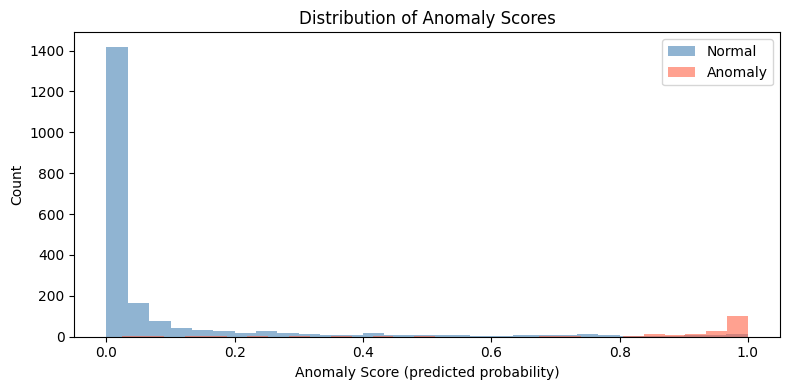

In [28]:
plt.figure(figsize=(8, 4))
plt.hist(y_scores_cv[y == 0], bins=30, alpha=0.6, label="Normal",   color="steelblue")
plt.hist(y_scores_cv[y == 1], bins=30, alpha=0.6, label="Anomaly",  color="tomato")
plt.xlabel("Anomaly Score (predicted probability)")
plt.ylabel("Count")
plt.title("Distribution of Anomaly Scores")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Train Final Model & Generate Submission

We refit on the full training set, then score the held-out test batch.

In [29]:
# Fit on ALL training data.
# Uses best_pipeline (tuned) if hyperparameter-tuning cell has been run,
# otherwise falls back to the default pipeline.
_fit_pipeline = best_pipeline if "best_pipeline" in dir() and best_pipeline is not None else pipeline
_fit_pipeline.fit(X_raw_combined, y)
pipeline.fit(X_raw_combined, y)   # always keep baseline fitted too
print("Model trained on full training set.")
if "best_pipeline" in dir() and best_pipeline is not None:
    print("Using tuned best_pipeline for submission.")
else:
    print("Hyperparameter tuning not run — using default pipeline.")

Model trained on full training set.
Hyperparameter tuning not run — using default pipeline.


In [30]:
# -- Helper: build test features matching the training pipeline exactly -----
#
# ROOT CAUSE OF THE ValueError:
#   SVDPlusHandcrafted.transform() slices X[:, :-N_HANDCRAFTED] to get the
#   user-item block. N_HANDCRAFTED is the number of columns in agg at the
#   time dim-reduction ran. After feature-engineering added DegSim,
#   cosine_sim_to_normal, and mahal_dist directly to agg, N_HANDCRAFTED grew.
#   But build_features_raw only called compute_handcrafted_features(), which
#   does NOT append those three cross-population columns — so X_test_combined
#   had fewer columns than training and the SVD slice was wrong.
#
# FIX: build_features_raw now appends all columns in exactly the same order
#   as feature-engineering does, using the training artefacts that are already
#   in memory (_ui_pearson, mean_normal_vec, lw).

from sklearn.metrics.pairwise import cosine_similarity as _cs_fn
from sklearn.preprocessing import normalize as _nfn_gs

def build_features_raw(X_interactions, all_items, recon_svd):
    """
    Build a feature matrix for any interaction batch that exactly matches
    the column layout seen by the pipeline at training time:
      [user-item pivot (aligned to training items)] +
      [compute_handcrafted_features columns]        +
      [degsim_pearson]                              +
      [top5_corating_overlap]                       +
      [cosine_sim_to_normal]                        +
      [mahal_dist]

    Uses all training artefacts from memory:
      _ui_pearson      — Pearson-normalised training user-item matrix
      mean_normal_vec  — centroid of normal training users
      lw               — fitted LedoitWolf covariance estimator
    """
    df = pd.DataFrame(X_interactions, columns=["user", "item", "rating"])

    # Align pivot to TRAINING item columns (fills unseen items with 0)
    pivot = df.pivot_table(
        index="user", columns="item", values="rating", aggfunc="mean"
    ).reindex(columns=all_items, fill_value=0).fillna(0)

    # Reconstruction error using TRAINING SVD
    _approx   = recon_svd.transform(pivot.values) @ recon_svd.components_
    recon_err = pd.Series(
        np.mean((pivot.values - _approx) ** 2, axis=1),
        index=pivot.index, name="recon_error",
    )

    # Handcrafted features (RDMA, WDMA, WDA, LengthVar, FMD, FMTD, MeanVar, etc.)
    agg_new = compute_handcrafted_features(df, recon_error=recon_err).loc[pivot.index]

    # -- DegSim (Pearson): test users vs TRAINING population -----------------
    # Mean-centre the test pivot, L2-normalise, dot with training Pearson matrix
    _DEGSIM_K_gs  = 20
    _te_centered  = pivot.values - pivot.values.mean(axis=1, keepdims=True)
    _te_pearson   = _nfn_gs(_te_centered, norm="l2")
    _sim_te_tr    = _te_pearson @ _ui_pearson.T           # (n_test, n_train)
    _degsim_test  = np.sort(_sim_te_tr, axis=1)[:, -_DEGSIM_K_gs:].mean(axis=1)
    agg_new["degsim_pearson"] = pd.Series(
        _degsim_test, index=pivot.index
    ).reindex(agg_new.index).fillna(0)

    # -- Co-rating overlap: test users vs TRAINING population ----------------
    _te_binary    = (pivot.values > 0).astype(np.float32)
    _te_bin_norm  = _nfn_gs(_te_binary, norm="l2")
    _tr_binary    = (user_item.values > 0).astype(np.float32)
    _tr_bin_norm  = _nfn_gs(_tr_binary, norm="l2")
    _overlap_te   = _te_bin_norm @ _tr_bin_norm.T         # (n_test, n_train)
    _top5_test    = np.sort(_overlap_te, axis=1)[:, -5:].mean(axis=1)
    agg_new["top5_corating_overlap"] = pd.Series(
        _top5_test, index=pivot.index
    ).reindex(agg_new.index).fillna(0)

    # -- Cosine similarity to TRAINING normal centroid -----------------------
    _cos_test = _cs_fn(pivot.values, mean_normal_vec).ravel()
    agg_new["cosine_sim_to_normal"] = pd.Series(
        _cos_test, index=pivot.index
    ).reindex(agg_new.index).fillna(0)

    # -- Mahalanobis distance using TRAINING LedoitWolf covariance -----------
    _mahal_test = np.sqrt(lw.mahalanobis(agg_new.values))
    agg_new["mahal_dist"] = pd.Series(
        _mahal_test, index=agg_new.index
    ).reindex(agg_new.index).fillna(0)

    return np.hstack([pivot.values, agg_new.values]), pivot.index.tolist()


# -- Score the test batch ----------------------------------------------------
data_test  = np.load(os.path.join(data_folder, "second_batch.npz"))
X_test_raw = data_test["X"]

all_items = user_item.columns.tolist()   # training item index

X_test_combined, test_users = build_features_raw(X_test_raw, all_items, _recon_svd)

# Sanity check — must match training width exactly
assert X_test_combined.shape[1] == X_raw_combined.shape[1], (
    f"Column mismatch: test={X_test_combined.shape[1]}, "
    f"train={X_raw_combined.shape[1]}. "
    f"Check that feature-engineering and build_features_raw add the same columns."
)
print(f"Feature matrix shape — train: {X_raw_combined.shape}  test: {X_test_combined.shape}")

score_pipeline = best_pipeline if "best_pipeline" in dir() and best_pipeline is not None else pipeline
anomaly_scores = score_pipeline.predict_proba(X_test_combined)[:, 1]

print(f"Scored {len(anomaly_scores)} users")
print(f"Score range  : [{anomaly_scores.min():.4f}, {anomaly_scores.max():.4f}]")
print(f"Mean score   : {anomaly_scores.mean():.4f}")

np.savez("submission_lr_raw.npz", predictions=anomaly_scores)
print("\nsubmission_lr.npz saved!")

Feature matrix shape — train: (2200, 1024)  test: (860, 1024)
Scored 860 users
Score range  : [0.0000, 1.0000]
Mean score   : 0.0516

submission_lr.npz saved!


## 8. (Optional) Hyperparameter Tuning

Run this cell to search over regularisation strength `C` and SVD components. This can meaningfully improve AUC.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_recall_curve as _prc_tune

# ==========================================================================
# Custom best-F1 scorer (threshold-free)
#
# sklearn's built-in "f1" scorer calls predict() at the default 0.5 threshold
# — wrong for 10:1 imbalanced data where the optimum is ~0.3-0.4.
# This callable scorer calls predict_proba(), sweeps the full PR curve, and
# returns the MAXIMUM F1 achievable at any threshold for that fold.
# Pass directly as scoring=best_f1_scorer — do NOT wrap with make_scorer().
# ==========================================================================
def best_f1_scorer(estimator, X, y_true):
    probs = estimator.predict_proba(X)[:, 1]
    pr, re, _ = _prc_tune(y_true, probs)
    denom = pr[:-1] + re[:-1]
    f1v = np.where(denom > 0,
                   2 * pr[:-1] * re[:-1] / np.maximum(denom, 1e-12), 0.0)
    return float(np.max(f1v))

_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==========================================================================
# Grid 1 — L2 regularisation (lbfgs solver)
#
# Searches n_components, C, and class_weight jointly.
# "balanced" auto-computes ~10:1 from the class ratio; explicit weights
# sweep the nearby space to find whether the optimum is slightly above
# or below that.
# ==========================================================================
print("=" * 60)
print("Grid 1  L2 regularisation (lbfgs)")
print("=" * 60)

_pipe_l2 = Pipeline([
    ("svd_hc", SVDPlusHandcrafted(n_components=30)),
    ("scaler", StandardScaler()),
    ("lr",     LogisticRegression(solver="lbfgs", max_iter=1000, random_state=42)),
])

param_grid_l2 = {
    "svd_hc__n_components": [40, 60, 80, 100, 120],
    "lr__C":                [0.01, 0.05, 0.1, 0.5],
    "lr__class_weight":     [
        "balanced",
        {0: 1, 1: 8},
        {0: 1, 1: 10},
        {0: 1, 1: 12},
        {0: 1, 1: 15},
    ],
}

grid_l2 = GridSearchCV(
    _pipe_l2, param_grid_l2,
    scoring=best_f1_scorer,
    cv=_skf, n_jobs=-1, verbose=0, refit=True,
)
grid_l2.fit(X_raw_combined, y)

print(f"Best n_components : {grid_l2.best_params_['svd_hc__n_components']}")
print(f"Best C            : {grid_l2.best_params_['lr__C']}")
print(f"Best class_weight : {grid_l2.best_params_['lr__class_weight']}")
print(f"Best CV F1        : {grid_l2.best_score_:.4f}")

# Top 5 results
_res_l2 = pd.DataFrame(grid_l2.cv_results_)
print(_res_l2[["param_svd_hc__n_components", "param_lr__C",
               "param_lr__class_weight", "mean_test_score"]]
      .sort_values("mean_test_score", ascending=False).head(5).to_string(index=False))


# ==========================================================================
# Grid 2 — ElasticNet regularisation (saga solver)
#
# WHY ElasticNet / L1 on top of L2:
# After SVD the feature matrix has 40-120 embedding dimensions of varying
# quality, plus ~14 handcrafted columns. L2 shrinks ALL coefficients equally
# — it cannot zero out weak SVD dimensions. L1 / ElasticNet CAN set
# coefficients exactly to zero, performing implicit feature selection inside
# the LR. This is valuable when some SVD components capture noise rather
# than shilling-attack signal.
#
# l1_ratio controls the mix:
#   l1_ratio = 1.0  → pure L1 (maximum sparsity, strongest selection)
#   l1_ratio = 0.5  → balanced ElasticNet
#   l1_ratio = 0.1  → mostly L2 with mild sparsity
#
# The saga solver is required for ElasticNet; it converges well on
# StandardScaler-normalised features (approximate same scale).
# max_iter=2000 because saga needs more iterations than lbfgs.
# ==========================================================================
print("\n" + "=" * 60)
print("Grid 2  ElasticNet regularisation (saga)")
print("=" * 60)

_pipe_en = Pipeline([
    ("svd_hc", SVDPlusHandcrafted(n_components=30)),
    ("scaler", StandardScaler()),
    ("lr",     LogisticRegression(
                   solver="saga",
                   penalty="elasticnet",
                   max_iter=2000,
                   random_state=42,
               )),
])

param_grid_en = {
    "svd_hc__n_components": [40, 60, 80, 100, 120],
    "lr__C":                [0.01, 0.05, 0.1, 0.5],
    "lr__l1_ratio":         [0.1, 0.5, 0.9, 1.0],
    "lr__class_weight":     [
        "balanced",
        {0: 1, 1: 10},
        {0: 1, 1: 12},
        {0: 1, 1: 15},
    ],
}

grid_en = GridSearchCV(
    _pipe_en, param_grid_en,
    scoring=best_f1_scorer,
    cv=_skf, n_jobs=-1, verbose=0, refit=True,
)
grid_en.fit(X_raw_combined, y)

print(f"Best n_components : {grid_en.best_params_['svd_hc__n_components']}")
print(f"Best C            : {grid_en.best_params_['lr__C']}")
print(f"Best l1_ratio     : {grid_en.best_params_['lr__l1_ratio']}")
print(f"Best class_weight : {grid_en.best_params_['lr__class_weight']}")
print(f"Best CV F1        : {grid_en.best_score_:.4f}")

_res_en = pd.DataFrame(grid_en.cv_results_)
print(_res_en[["param_svd_hc__n_components", "param_lr__C",
               "param_lr__l1_ratio", "param_lr__class_weight", "mean_test_score"]]
      .sort_values("mean_test_score", ascending=False).head(5).to_string(index=False))


# ==========================================================================
# Select winner and evaluate with per-fold threshold averaging
# ==========================================================================
print("\n" + "=" * 60)
print("Summary")
print("=" * 60)
print(f"L2  best CV F1 : {grid_l2.best_score_:.4f}")
print(f"EN  best CV F1 : {grid_en.best_score_:.4f}")

if grid_en.best_score_ >= grid_l2.best_score_:
    best_pipeline = grid_en.best_estimator_
    _winner = "ElasticNet (saga)"
    _winner_score = grid_en.best_score_
else:
    best_pipeline = grid_l2.best_estimator_
    _winner = "L2 (lbfgs)"
    _winner_score = grid_l2.best_score_

print(f"Winner: {_winner}  (CV F1 = {_winner_score:.4f})")

# Evaluate winner with per-fold threshold averaging
y_scores_best = cross_val_predict(
    best_pipeline, X_raw_combined, y,
    cv=_skf, method="predict_proba",
)[:, 1]

_best_thresholds = []
for _tr_idx, _val_idx in _skf.split(X_raw_combined, y):
    _c = best_pipeline
    _c.fit(X_raw_combined[_tr_idx], y[_tr_idx])
    _pr_b, _re_b, _th_b = _prc_tune(y[_val_idx],
                                      _c.predict_proba(X_raw_combined[_val_idx])[:, 1])
    _d = _pr_b[:-1] + _re_b[:-1]
    _f = np.where(_d > 0, 2 * _pr_b[:-1] * _re_b[:-1] / np.maximum(_d, 1e-12), 0.0)
    if len(_th_b) > 0:
        _best_thresholds.append(float(_th_b[np.argmax(_f)]))

best_f1_threshold_tuned = float(np.mean(_best_thresholds)) if _best_thresholds else 0.5
y_pred_best = (y_scores_best >= best_f1_threshold_tuned).astype(int)

print(f"\n=== Tuned {_winner} — cross-validated ===")
print(f"AUC       : {roc_auc_score(y, y_scores_best):.4f}  "
      f"(baseline: {roc_auc_score(y, y_scores_cv):.4f})")
print(f"F1 thresh : {best_f1_threshold_tuned:.4f}  "
      f"(per-fold: {[f'{t:.3f}' for t in _best_thresholds]})")
print(f"Precision : {precision_score(y, y_pred_best):.4f}")
print(f"Recall    : {recall_score(y, y_pred_best):.4f}")
print(f"F1        : {f1_score(y, y_pred_best):.4f}  "
      f"(baseline: {f1_score(y, y_pred_cv):.4f})")
print()
print(classification_report(y, y_pred_best, target_names=["Normal", "Anomaly"]))

Grid 1  L2 regularisation (lbfgs)
Best n_components : 60
Best C            : 0.5
Best class_weight : {0: 1, 1: 8}
Best CV F1        : 0.8265
 param_svd_hc__n_components  param_lr__C param_lr__class_weight  mean_test_score
                         60          0.5           {0: 1, 1: 8}         0.826544
                         60          0.5          {0: 1, 1: 10}         0.826111
                         60          0.5          {0: 1, 1: 12}         0.824051
                         60          0.5          {0: 1, 1: 15}         0.822832
                         40          0.5          {0: 1, 1: 12}         0.822137

Grid 2  ElasticNet regularisation (saga)
